In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import gc
class FrequencyConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super(FrequencyConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding if isinstance(padding, tuple) else (padding, padding)
        
        self.weight = nn.Parameter(torch.randn(out_channels, in_channels, self.kernel_size[0], self.kernel_size[1]))
        if bias:
            self.bias = nn.Parameter(torch.randn(out_channels))
        else:
            self.bias = None
        
        # 预计算一些常量
        self.register_buffer('use_frequency_domain', torch.tensor(True))

    def forward(self, x):
        # 动态选择卷积方式
        kernel_area = self.kernel_size[0] * self.kernel_size[1]
        input_area = x.shape[2] * x.shape[3]
        
        # 经验规则：大kernel或大输入时使用频域卷积
        if kernel_area > 64 or input_area > 4096:
            return self._frequency_conv(x)
        else:
            return F.conv2d(x, self.weight, self.bias, self.stride, self.padding)
    
    def _frequency_conv(self, x):
        batch_size, in_channels, H, W = x.shape
        
        if self.padding != (0, 0):
            x_padded = F.pad(x, (self.padding[1], self.padding[1], self.padding[0], self.padding[0]))
        else:
            x_padded = x
        
        padded_H, padded_W = x_padded.shape[-2:]
        
        kernel_flipped = torch.flip(self.weight, [2, 3])
        kernel_padded = F.pad(kernel_flipped, (0, padded_W - self.kernel_size[1], 0, padded_H - self.kernel_size[0]))
        
        x_fft = torch.fft.fft2(x_padded, dim=(-2, -1))
        kernel_fft = torch.fft.fft2(kernel_padded, dim=(-2, -1))
        
        output_fft = torch.einsum('bihw,oihw->bohw', x_fft, kernel_fft)
        output_full = torch.fft.ifft2(output_fft, dim=(-2, -1)).real
        
        start_h = self.kernel_size[0] - 1
        start_w = self.kernel_size[1] - 1
        end_h = start_h + H
        end_w = start_w + W
        output = output_full[:, :, start_h:end_h, start_w:end_w]
        
        if self.stride != (1, 1):
            output = output[:, :, ::self.stride[0], ::self.stride[1]]
        
        if self.bias is not None:
            output += self.bias.view(1, -1, 1, 1)
        
        return output

In [33]:
def benchmark(batch_size=4,channels=3,test_range=range(3,32,2)):
    times_freq=[]
    times_normal=[]
    x=torch.randn(batch_size, channels, 512, 512)
    for i,k in enumerate(test_range):
        p=i+1
        freq_conv = FrequencyConv2d(
            in_channels=channels, 
            out_channels=channels, 
            kernel_size=k, 
            stride=1, 
            padding=p, 
            bias=True)
        normal_conv = nn.Conv2d(
            in_channels=channels, 
            out_channels=channels, 
            kernel_size=k, 
            stride=1, 
            padding=p, 
            bias=True)
        normal_conv.weight.data = freq_conv.weight.data.clone()
        normal_conv.bias.data = freq_conv.bias.data.clone()
        start_time=time.time()
        x=freq_conv(x)
        total_time=time.time()-start_time
        times_freq.append(total_time)
        start_time=time.time()
        x=normal_conv(x)
        total_time=time.time()-start_time
        times_normal.append(total_time)
        gc.collect()
    return times_normal,times_freq

In [8]:
freq_conv = FrequencyConv2d(
        in_channels=3, 
        out_channels=3, 
        kernel_size=3, 
        stride=1, 
        padding=1, 
        bias=True)
normal_conv = nn.Conv2d(
        in_channels=3, 
        out_channels=3, 
        kernel_size=3, 
        stride=1, 
        padding=1, 
        bias=True)
normal_conv.weight.data = freq_conv.weight.data.clone()
normal_conv.bias.data = freq_conv.bias.data.clone()

In [9]:
x=torch.randn(4, 3, 512, 512)
with torch.no_grad():
    output_freq = freq_conv(x)
    output_normal = normal_conv(x)
    print(f"\n输入形状: {x.shape}")
    print(f"频域卷积输出形状: {output_freq.shape}")
    print(f"普通卷积输出形状: {output_normal.shape}")
    print(f"结果差异: {torch.abs(output_freq - output_normal).max().item():.6f}")


输入形状: torch.Size([4, 3, 512, 512])
频域卷积输出形状: torch.Size([4, 3, 512, 512])
普通卷积输出形状: torch.Size([4, 3, 512, 512])
结果差异: 0.000019


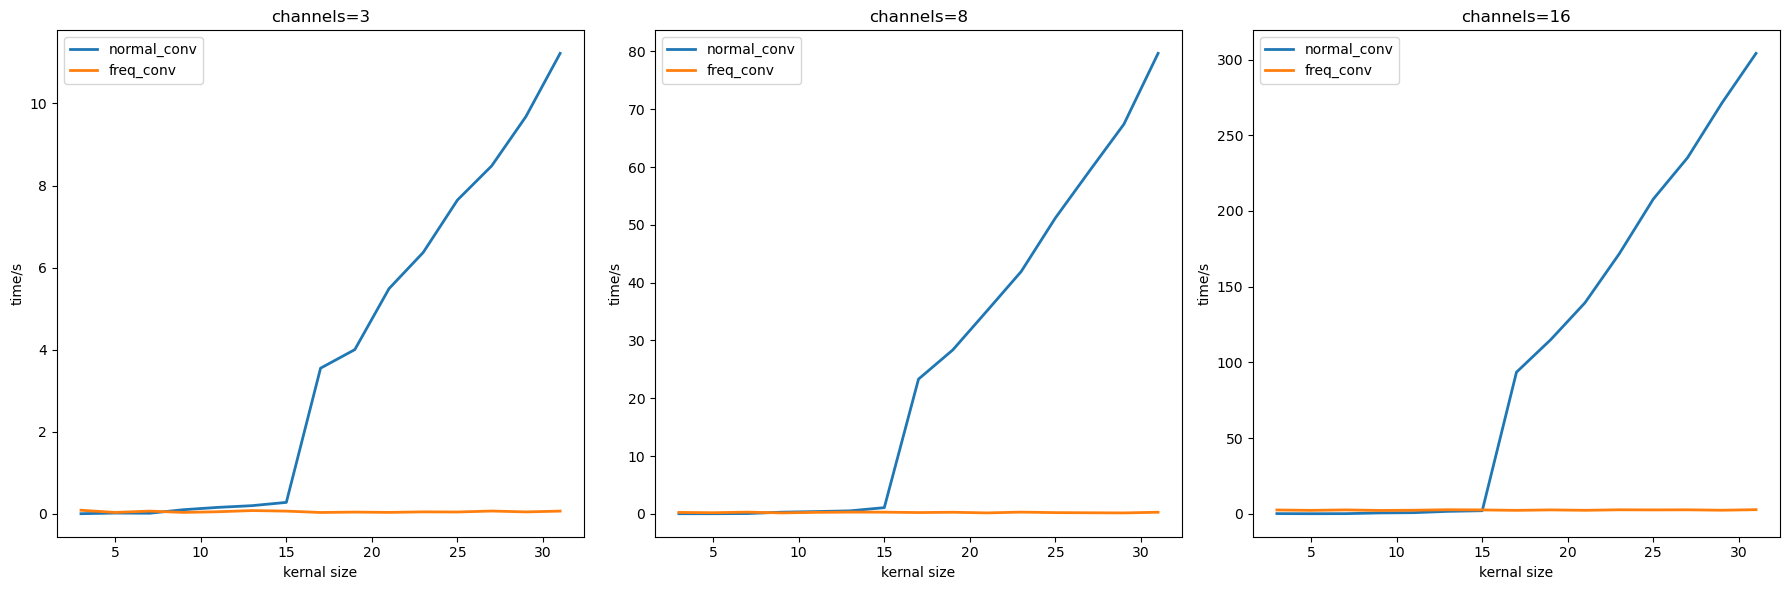

In [39]:
test_channels_list=[3,8,16]
test_range=range(3,32,2)
test_batch_size=4
plt.figure(figsize=(18, 6))
for i,test_channels in enumerate(test_channels_list):
    times_normal,times_freq=benchmark(batch_size=test_batch_size,channels=test_channels,test_range=test_range)
    plt.subplot(1,3,i+1)
    plt.plot(test_range,times_normal,label="normal_conv",linewidth=2)
    plt.plot(test_range,times_freq,label="freq_conv",linewidth=2)
    plt.title(f"channels={test_channels}")
    plt.xlabel("kernal size")
    plt.ylabel("time/s")
    plt.legend()
plt.tight_layout()
plt.show()

In [36]:
gc.collect()

11135

$$\alpha = \begin{bmatrix} a1 \\ a2 \\a3 \\ a4 \\ a5 \\a6 \end{bmatrix}, \quad 
L=\begin{bmatrix} \mathcal{L}_{recon} \\ \mathcal{L}_{perc} \\\mathcal{L}_{grad} \\ \mathcal{L}_{ssim} \\ \mathcal{L}_{color} \\\mathcal{L}_{texture} \end{bmatrix}$$
$$\mathcal{L}_{total} = a1 \mathcal{L}_{recon} + a2 \mathcal{L}_{perc} + a3 \mathcal{L}_{grad} + a4 \mathcal{L}_{ssim} + a5 \mathcal{L}_{color} + a6 \mathcal{L}_{texture}=\mathbf{\alpha}^T \mathbf{L}$$
$$\mathcal{L}_{recon} = \frac{1}{N} \sum_{i=1}^{N} |G_i - T_i|$$

$$\mathcal{L}_{perc} = \frac{1}{L} \sum_{l \in \{3,6,11,15\}} \frac{1}{C_l H_l W_l} \|\phi_l(G) - \phi_l(T)\|_2^2$$

$$\mathcal{L}_{grad} = \frac{1}{N} \sum_{i=1}^{N} (|\nabla_x G_i - \nabla_x T_i| + |\nabla_y G_i - \nabla_y T_i|)$$


Sobel算子：$$\nabla_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad
\nabla_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

$$\mathcal{L}_{ssim} = 1 - SSIM(G,T)$$


SSIM计算：$$SSIM(G,T) = \frac{(2\mu_G\mu_T + c_1)(2\sigma_{GT} + c_2)}{(\mu_G^2 + \mu_T^2 + c_1)(\sigma_G^2 + \sigma_T^2 + c_2)}$$

$$\mathcal{L}_{color} = \gamma_{1} \mathcal{L}_{hist} + \gamma_{2} \mathcal{L}_{lab},\quad where\quad \gamma_{1}=0.3, \gamma_{2}=0.7$$


直方图匹配损失：$$\mathcal{L}_{hist} = \frac{1}{3B} \sum_{b=1}^{B} \sum_{c=1}^{3} \|H_{G_{b,c}} - H_{T_{b,c}}\|_2^2$$


Lab空间损失：$$\mathcal{L}_{lab} = \frac{1}{N} \sum_{i=1}^{N} |Lab(G)_i - Lab(T)_i|$$

纹理损失：$$\mathcal{L}_{texture} = \frac{1}{N} \sum_{i=1}^{N} |\sigma_G^2(i) - \sigma_T^2(i)|$$

